<a href="https://colab.research.google.com/github/seojoon1/2026_bigdatacomputing/blob/main/class_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ 데이터 과학 파이프라인의 전 과정
- Numpy : 다차원 배열 생성, 결합(concatenate(), vstack(),hstack(), column_stack()), 셔플링, 필터링(인덱싱/슬라이싱)

- Pandas : 데이터 구조화, 타입 변환, 그룹 분석(groupby(), pivot_table(), concat(), merge()), 데이터 추출(인덱싱, 슬라이싱), 결측치 보간(fillna(), isna(), dropna())

- 시각화 : matplotlib, seaborn, Pandas의 시각화 기능, DataFrame의 시각화 기능

- 데이터 분석 흐름: 데이터 생성(Numpy) → 데이터 구조화(Pandas) → 정제(Pre-processing) → 탐색적 데이터 분석(EDA) : 시각화 순서로 진행

- NumPy 기반의 시뮬레이션 코드를 Pandas의 DataFrame 구조로 확장하면, 데이터에 이름을 붙이고(Indexing), 통계치를 한눈에 확인하며, 시각화 라이브러리와의 연동




## ✅ Pandas 기능

In [ ]:
#======================
# Series: List
#======================

import pandas as pd
import numpy as np

s = pd.Series([1, 3, 5, np.nan, 6, 8])
s = pd.Series(np.random.randn(5))
s = pd.Series(np.random.randn(5), index = [1, 2, 3, 4, 5])
print("\n",s)
# 이름 지정 데이터타입 확인
s = pd.Series(np.random.randint(60,90,5), name="score")
print("\n",type(s))
# 결측치 확인
s = pd.Series([1, 3, 5, np.nan, 6, 8])
print(s.isna())
# 시리즈 값 추출
print(s[0])
# 시리즈의 인덱스 변경
s = pd.Series([1, 3, 5, np.nan, 6, 8], index= [1,2,3,4,5,6])
print("\n",s)
s = pd.Series([1, 3, 5, np.nan, 6, 8])
s.index = [1,2,3,4,5,6]
print("\n",s)
# 시리즈의 값 수정

s = pd.Series([1, 3, 5, np.nan, 6, 8])
s[3] = 0

# 시리즈의 새 값 추가

s = pd.Series([1, 3, 5, np.nan, 6, 8])
s[7] = 0






 1    0.458426
2    1.061247
3    0.232239
4   -0.410333
5   -0.666429
dtype: float64

 <class 'pandas.core.series.Series'>
0    False
1    False
2    False
3     True
4    False
5    False
dtype: bool
1.0

 1    1.0
2    3.0
3    5.0
4    NaN
5    6.0
6    8.0
dtype: float64

 1    1.0
2    3.0
3    5.0
4    NaN
5    6.0
6    8.0
dtype: float64


In [ ]:
#+===
# Series: dictionary
#+===

income ={'jan':8000, 'tal':1557, 'kim':888484}
income_s = pd.Series(income, name = "salary")
print(income_s)
print(income_s.index.to_list())
print(income_s.values)
income_s.index = ['1M','2M','3M']
print('\n',income_s)
# 최대값
print('\n',income_s.max())
max_index = np.argmax(income_s)
print('\n',max_index)
print('\n',income_s[max_index])


jan      8000
tal      1557
kim    888484
Name: salary, dtype: int64
['jan', 'tal', 'kim']
[  8000   1557 888484]

 1M      8000
2M      1557
3M    888484
Name: salary, dtype: int64

 888484

 2

 888484


/tmp/ipykernel_968/3661807818.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('\n',income_s[max_index])


In [ ]:

#-----------------
# DataFrame : 복수 개의 시리즈를 딕셔너리로 이용
#-----------------

month_s = pd.Series(['jan','feb','mar'])
income_s = pd.Series([9700, 1557, 88484])
expanse_s = pd.Series([5040, 1337, 8090])

df = pd.DataFrame({'month':month_s, 'income':income_s, 'expanse':expanse_s}, index = range(1,4))
print(df)
# df의 속성
print("\n",df.index.to_list())
print("\n",df.columns.to_list())
print("\n",df.values)
# df값 추출
# (1) 인덱싱
print("\n",df['month'])
print("\n",df.month)
# (2) 슬라이싱

df.index = ['M1','M2','M3']
print("\n",df.loc['M1'])

# 특정 행 추출
# print("\n",df.loc["M1"])
# print("\n",df.loc["M1","M3"])

# 데이터프레임의 특정 데이터 추출
print("\n",df.loc["M1",'income'])

  month   income  expanse
1   feb   1557.0   1337.0
2   mar  88484.0   8090.0
3   NaN      NaN      NaN

 [1, 2, 3]

 ['month', 'income', 'expanse']

 [['feb' 1557.0 1337.0]
 ['mar' 88484.0 8090.0]
 [nan nan nan]]

 1    feb
2    mar
3    NaN
Name: month, dtype: object

 1    feb
2    mar
3    NaN
Name: month, dtype: object

 month         feb
income     1557.0
expanse    1337.0
Name: M1, dtype: object

 1557.0


In [ ]:
# ==============
# DF합치기 : pd.concat()
# ==============
df1 = pd.DataFrame({'A': ['A0', 'A1'], 'B': ['B0', 'B1']})
df2 = pd.DataFrame({'A': ['A2', 'A3'], 'B': ['B2', 'B3']})
df2 = pd.DataFrame({'C': ['A2', 'A3']})
df4 = pd.DataFrame({'D': ['A2']})

result = pd.concat([df1, df2], axis=0, join="outer") #outer 행에대한 합집합
print(result)


     A    B    C
0   A0   B0  NaN
1   A1   B1  NaN
0  NaN  NaN   A2
1  NaN  NaN   A3


In [3]:
import pandas as pd
#==================
# 두 개의 1월과 2월의 매출 표 생성
#==================

jan = pd.DataFrame({'매출': [100,200]}, index = ['a상품','b상품'])
print(jan)

#===============
#4

      매출
a상품  100
b상품  200


#### 응용문제: 데이터 통합 및 결측치 제어 및 seaborn 시각화

✅ 환경 설정 및 한글 폰트 로드 완료

     기온
5월  20
6월  22
7월  25

       기온   풍속
5월  20.0  3.2
6월   NaN  4.1
8월  25.0  3.8

결합직후
             기온   풍속
2021년 5월  20.0  NaN
      6월  22.0  NaN
      7월  25.0  NaN
2022년 5월  20.0  3.2
      6월   NaN  4.1
      8월  25.0  3.8
MultiIndex([('2021년', '5월'),
            ('2021년', '6월'),
            ('2021년', '7월'),
            ('2022년', '5월'),
            ('2022년', '6월'),
            ('2022년', '8월')],
           )
Index(['2021년', '2021년', '2021년', '2022년', '2022년', '2022년'], dtype='object')
Index(['5월', '6월', '7월', '5월', '6월', '8월'], dtype='object')

결측치 처리 후
             기온   풍속
2021년 5월  20.0  0.0
      6월  22.0  0.0
      7월  25.0  0.0
2022년 5월  20.0  3.2
      6월  22.4  4.1
      8월  25.0  3.8


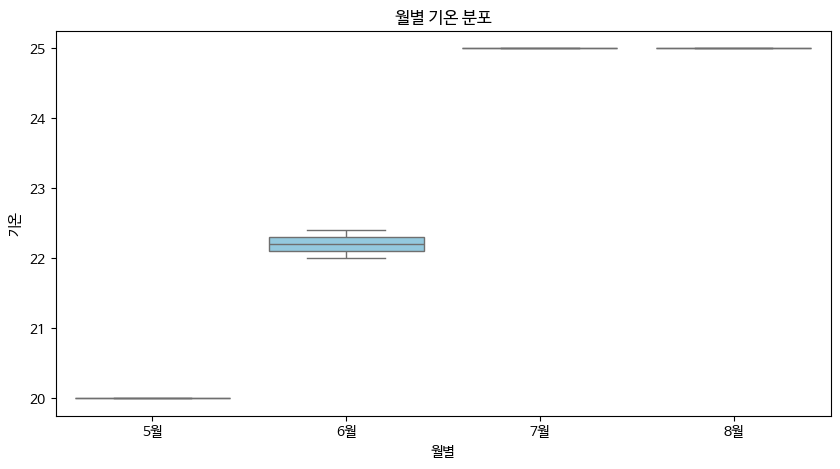

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

#단계[2] 샘플 데이터 생성 (현업 상황 시뮬레이터)
df_2021 = pd.DataFrame({'기온':[20,22,25]},index =['5월','6월','7월'])
df_2022 = pd.DataFrame({'기온':[20,np.nan,25], '풍속':[3.2,4.1,3.8]},index =['5월','6월','8월'])

print("\n",df_2021)
print("\n",df_2022)

#단계[3] 모든 월과 컬럼을 유지하면서 물리적으로 결합 (axios = 0, join = 'outer')

combined = pd.concat([df_2021, df_2022], axis=0, join='outer', keys = ['2021년','2022년'])
print("\n결합직후\n",combined)
print("=============")
print(combined.index)
print(combined.index.get_level_values(0))
print(combined.index.get_level_values(1))
#4 결측치 처리 df.fillna
print("=========================")
clean_df = combined.fillna({
    '기온': combined['기온'].mean(),
    '풍속': 0.0 #풍속 데이터가 없을 시 0으로 출력
})
print("\n결측치 처리 후\n",clean_df)
# 5 시본 맵플로릿으로 시각화 박스플롯으로 분포 확인

print("=========================")
plt.figure(figsize=(10, 5))
sns.boxplot(data=clean_df, x = clean_df.index.get_level_values(1), y = '기온', color = 'skyblue')
plt.xlabel("월별")
plt.title("월별 기온 분포")
plt.show()


## pandas 기능
- pd.merge ()

In [41]:
#===================
# df 병합 :공유하는 특정  키 열을 기준으로 테이블을 결합: merge()
#===================
df_customer = pd.DataFrame({'ID':[1,2,3] , "Name":['김','이','박']}, index = ['가','나','다'])
print(df_customer)

df_purchase_items = pd.DataFrame({'ID':[2,3,4,5],'Product': ['스마트폰','노트북','태블릿','컴퓨터']}, index=['다','라','마','바'])
print("\n",df_purchase_items)

#==================
# 1. ID 번호가 같은 사람들끼리 정보 행을 합치기 : on="ID", how = "inner"
#==================
# 행번호는 자동으로 ID의 공통 개수만큼 생성, 컬럼명은 모두 나옴
inner_res = pd.merge(df_customer, df_purchase_items, on="ID", how="inner")
print("\n",inner_res)

#================
# 2. ID를 기준으로 구매한 모든 정보 합치기: on = 'ID', how = "outer"
#================
outer_res = pd.merge(df_customer, df_purchase_items, on="ID", how="outer")
print("\n",outer_res)

#=================
#  3. 왼쪽 테이블 : 기준이 되는 마스터 명부 에 정보를 덧붙이기 . on = 'ID', Left Join -how ='left'
#=================
# 행 번호는 자동으로 왼쪽 테이블 ID의 전체 개수만큼 생성, 컬럼명은 모두 나옴:
# 오른쪽 데이터프레임에는 없는 id라면 해당 열을 NaN
print("\n3================\n")
left_res = df_customer.merge(df_purchase_items, on="ID", how="left")
print("\n",left_res)
#=================
#  4. 오른쪽 테이블 : 주문 기록을 기준으로 정보를 덧붙이기. on = 'ID', Right Outer Join how ='right
#=================
print("\n4================\n")
right_res = df_customer.merge(df_purchase_items, on="ID", how="right")
print("\n",right_res)

   ID Name
가   1    김
나   2    이
다   3    박

    ID Product
다   2    스마트폰
라   3     노트북
마   4     태블릿
바   5     컴퓨터

    ID Name Product
0   2    이    스마트폰
1   3    박     노트북

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  NaN     태블릿
4   5  NaN     컴퓨터

3================


    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북

4================


    ID Name Product
0   2    이    스마트폰
1   3    박     노트북
2   4  NaN     태블릿
3   5  NaN     컴퓨터


## pandas 기능
- pd.pivot_table()
- pd.pivot()


In [61]:
df_A = pd.DataFrame({'ID':[1,2,3] , "Name":['김','이','박']})
df_B = pd.DataFrame({'ID':[2,3,4,5],'Product': ['스마트폰','노트북','태블릿','컴퓨터']})

# 데이터 병합 ID를 기준으로 모든 고객과 구매 정보를 유지하도록 병합(merge)

merge_df = df_A.merge( df_B, on="ID", how="outer")
print(merge_df)
# 데이터 가공 (피벗 전처리)
# Name열에서 Name이 없는 경우 비회원으로 채우고 업데이트
merge_df['Name'] = merge_df['Name'].fillna('비회원')
print("\n비회원 전처리" ,merge_df)
# 각 구매 수량을 1로 표시하는 '구매수량' 컬럼 추가
merge_df['구매수량'] = 1
# 피벗 테이블 생성
# index는 고객 이름 컬럼은 상품명으로 설정하여 구매 수량을 집계
pivot_table = merge_df.pivot_table(index = 'Name', columns = 'Product', values = '구매수량', aggfunc ='sum')
pivot_res = pivot_table.fillna(0).astype(int)
print("\n",pivot_res)

   ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  NaN     태블릿
4   5  NaN     컴퓨터

비회원 전처리    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  비회원     태블릿
4   5  비회원     컴퓨터

 Product  노트북  스마트폰  컴퓨터  태블릿
Name                        
박          1     0    0    0
비회원        0     0    1    1
이          0     1    0    0


## ✅ 시계열 날씨 데이터
- 웹상의 CSV 데이터를 읽어와 전처리(결측치 처리, 날짜 변환)를 수행하고,
- concat, merge, pivot_table 등 Pandas의 핵심 기능을 모두 포함한 통합 데이터 분석 파이프라인 코드를 작성.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

#-----------------------------------------------------------------
# 데이터 로드
#-----------------------------------------------------------------
path = 'https://github.com/dongupak/DataML/raw/main/csv/'
weather = pd.read_csv(path + 'weather.csv', index_col=0, encoding='CP949')
print(weather.head())

✅ 환경 설정 및 한글 폰트 로드 완료
            평균기온  최대풍속  평균풍속
일시                          
2010-08-01  28.7   8.3   3.4
2010-08-02  25.2   8.7   3.8
2010-08-03  22.1   6.3   2.9
2010-08-04  25.3   6.6   4.2
2010-08-05  27.2   9.1   5.6
